<a href="https://colab.research.google.com/github/jenny005/Reinforcement-Learning-by-Sutton-Barto/blob/main/Chapter_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Example 9.1

## Gradient Monte Carlo Algorithm for Estimating

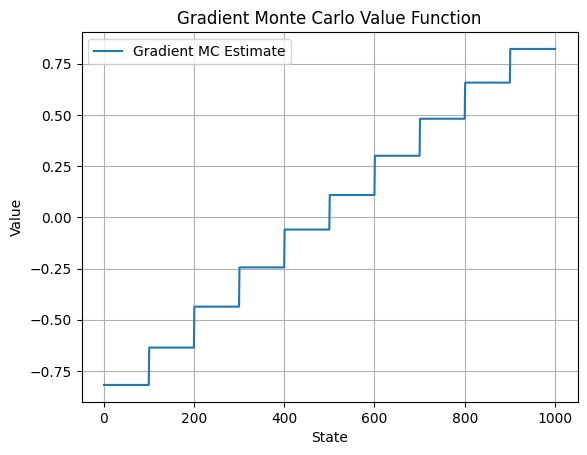

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
N_STATES = 1000
START_STATE = 500
END_STATES = [0, N_STATES + 1]
ACTION_LEFT = -1
ACTION_RIGHT = 1
STEP_RANGE = 100
STATES = np.arange(1, N_STATES + 1)

# --- Environment Step ---
def step(state, action):
    stride = np.random.randint(1, STEP_RANGE + 1)
    next_state = state + action * stride
    next_state = max(0, min(N_STATES + 1, next_state))
    reward = -1 if next_state == 0 else 1 if next_state == N_STATES + 1 else 0
    return next_state, reward

# --- Random Action ---
def get_action():
    return ACTION_RIGHT if np.random.rand() < 0.5 else ACTION_LEFT

# --- Value Function using State Aggregation (10 groups) ---
class ValueFunction:
    def __init__(self, num_groups=10):
        self.group_size = N_STATES // num_groups
        self.params = np.zeros(num_groups)

    def value(self, state):
        if state in END_STATES:
            return 0
        idx = (state - 1) // self.group_size
        return self.params[idx]

    def update(self, delta, state):
        if state in END_STATES:
            return
        idx = (state - 1) // self.group_size
        self.params[idx] += delta

# --- Gradient Monte Carlo Algorithm ---
def gradient_mc(value_function, alpha, num_episodes=100000):
    for ep in range(num_episodes):
        state = START_STATE
        trajectory = [state]
        while state not in END_STATES:
            action = get_action()
            state, _ = step(state, action)
            trajectory.append(state)

        final_reward = -1 if trajectory[-1] == 0 else 1 if trajectory[-1] == N_STATES + 1 else 0

        for s in trajectory[:-1]:
            delta = alpha * (final_reward - value_function.value(s))
            value_function.update(delta, s)

# --- Plotting Function ---
def plot_mc(vf):
    approx = [vf.value(s) for s in STATES]
    plt.plot(STATES, approx, label='Gradient MC Estimate')
    plt.xlabel('State'); plt.ylabel('Value'); plt.legend()
    plt.title('Gradient Monte Carlo Value Function')
    plt.grid(True)
    plt.show()

# --- Run ---
vf = ValueFunction(num_groups=10)
gradient_mc(vf, alpha=2e-5, num_episodes=100000)
plot_mc(vf)


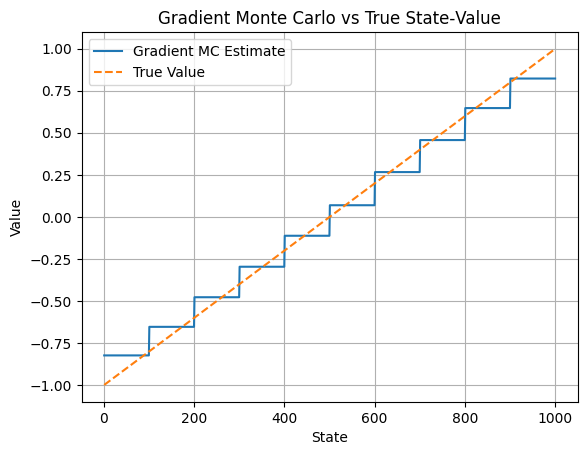

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
N_STATES    = 1000
START_STATE = 500
END_STATES  = [0, N_STATES + 1]
ACTION_LEFT  = -1
ACTION_RIGHT = 1
STEP_RANGE   = 100
STATES       = np.arange(1, N_STATES + 1)

# --- Environment Step ---
def step(state, action):
    stride = np.random.randint(1, STEP_RANGE + 1)
    next_state = state + action * stride
    next_state = max(0, min(N_STATES + 1, next_state))
    if   next_state == 0:
        reward = -1
    elif next_state == N_STATES + 1:
        reward = +1
    else:
        reward = 0
    return next_state, reward

# --- Random Policy ---
def get_action():
    return ACTION_RIGHT if np.random.rand() < 0.5 else ACTION_LEFT

# --- State‑Aggregation Value Function ---
class ValueFunction:
    def __init__(self, num_groups=10):
        self.group_size = N_STATES // num_groups
        self.params     = np.zeros(num_groups)

    def value(self, state):
        if state in END_STATES:
            return 0.0
        idx = (state - 1) // self.group_size
        return self.params[idx]

    def update(self, delta, state):
        if state in END_STATES:
            return
        idx = (state - 1) // self.group_size
        self.params[idx] += delta

# --- Gradient Monte Carlo ---
def gradient_mc(value_function, alpha, num_episodes=100000):
    for ep in range(num_episodes):
        state = START_STATE
        trajectory = [state]

        # generate an episode
        while state not in END_STATES:
            action = get_action()
            state, _ = step(state, action)
            trajectory.append(state)

        # final reward G
        final_reward = -1 if trajectory[-1] == 0 else +1

        # update each visited state
        for s in trajectory[:-1]:
            error = final_reward - value_function.value(s)
            delta = alpha * error
            value_function.update(delta, s)

# --- Plotting with True Value ---
def plot_mc(vf):
    approx = [vf.value(s) for s in STATES]
    v_true = -1 + 2 * STATES / (N_STATES + 1)

    plt.plot(STATES, approx, label='Gradient MC Estimate')
    plt.plot(STATES, v_true,   label='True Value', linestyle='--')

    plt.xlabel('State')
    plt.ylabel('Value')
    plt.title('Gradient Monte Carlo vs True State‑Value')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Run ---
if __name__ == '__main__':
    vf = ValueFunction(num_groups=10)
    gradient_mc(vf, alpha=2e-5, num_episodes=100000)
    plot_mc(vf)


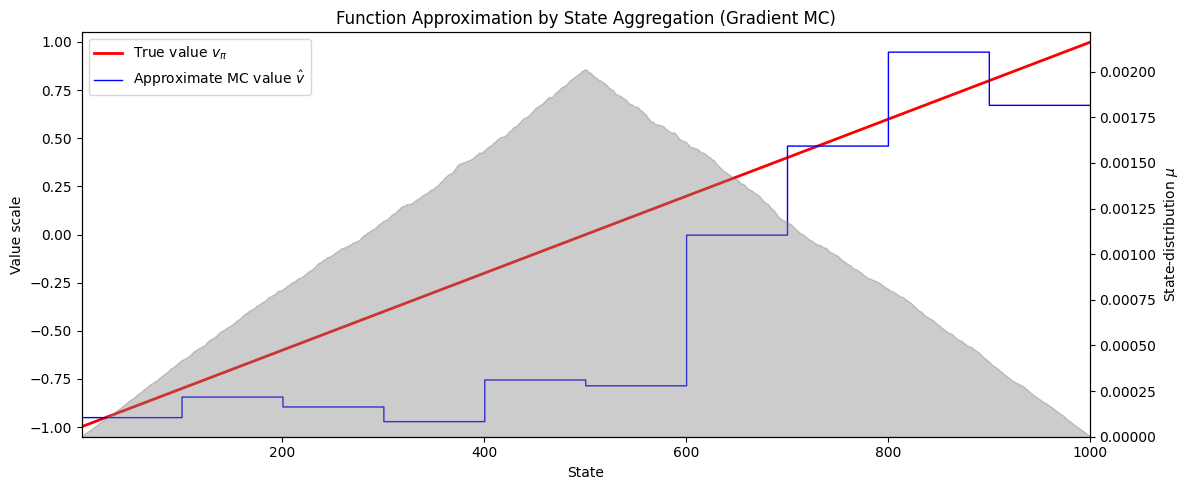

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
N = 1000                 # number of nonterminal states (1 to N)
start_state = N // 2     # starting at the middle state
n_groups = 10            # number of aggregates
group_size = N // n_groups
alpha = 2e-5             # step-size for gradient MC
n_episodes = 3000        # number of episodes for demonstration

# Initialize weights (one per group) and state-visit counts
w = np.zeros(n_groups)
mu_counts = np.zeros(N)

# Run gradient Monte Carlo over episodes
for ep in range(n_episodes):
    state = start_state
    trajectory = []
    # Generate an episode
    while True:
        trajectory.append(state)
        if np.random.rand() < 0.5: # random walk: move left or right with p=0.5
            state -= 1
        else:
            state += 1
        if state == 0:             # LEFT terminal
            reward = -1
            break
        if state == N + 1:         # RIGHT terminal
            reward = +1
            break

    # Track state visitation counts
    for s in trajectory:
        mu_counts[s - 1] += 1

    # Gradient MC updates ---------------------------
    for s in trajectory:
        grp = (s - 1) // group_size
        v_hat = w[grp]
        w[grp] += alpha * (reward - v_hat)

# Calculate approximate and true values
states = np.arange(1, N + 1)
v_true = -1 + 2 * states / (N + 1)
v_approx = np.array([w[(s - 1) // group_size] for s in states])

# Estimate state-distribution (mu)
mu = mu_counts / mu_counts.sum()

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 5))

# Value estimates
ax1.plot(states, v_true, 'r-', linewidth=2, label='True value $v_\\pi$')
ax1.step(states, v_approx, where='mid', color='b', label='Approximate MC value $\\hat v$', linewidth=1)
ax1.set_xlabel('State')
ax1.set_ylabel('Value scale')
ax1.set_xlim(1, N)
ax1.set_ylim(-1.05, 1.05)

# Distribution on secondary axis
ax2 = ax1.twinx()
ax2.fill_between(states, mu, color='gray', alpha=0.4)
ax2.set_ylabel('State-distribution $\\mu$')
ax2.set_ylim(0, mu.max() * 1.1)

# Legends and layout
ax1.legend(loc='upper left')
plt.title('Function Approximation by State Aggregation (Gradient MC)')
plt.tight_layout()
plt.show()


# Example 9.2

## Semi-Gradient TD

100%|██████████| 100000/100000 [00:57<00:00, 1748.02it/s]


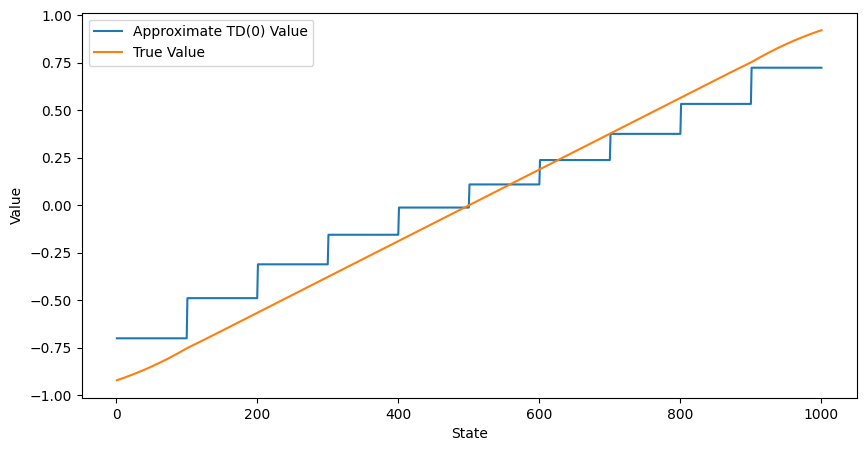

In [13]:
# In Colab, run this cell first to enable inline plotting:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# # of states except for terminal states
N_STATES = 1000

# all states
STATES = np.arange(1, N_STATES + 1)

# start from a central state
START_STATE = 500

# terminal states
END_STATES = [0, N_STATES + 1]

# possible actions
ACTION_LEFT = -1
ACTION_RIGHT = 1
ACTIONS = [ACTION_LEFT, ACTION_RIGHT]

# maximum stride for an action
STEP_RANGE = 100

def compute_true_value():
    true_value = np.arange(-1001, 1003, 2) / 1001.0
    while True:
        old_value = np.copy(true_value)
        for state in STATES:
            true_value[state] = 0
            for action in ACTIONS:
                for step_size in range(1, STEP_RANGE + 1):
                    next_state = state + action * step_size
                    next_state = max(min(next_state, N_STATES + 1), 0)
                    true_value[state] += 1.0 / (2 * STEP_RANGE) * true_value[next_state]
        if np.sum(np.abs(old_value - true_value)) < 1e-2:
            break
    true_value[0] = true_value[-1] = 0
    return true_value


def step(state, action):
    stride = np.random.randint(1, STEP_RANGE + 1) * action
    next_state = state + stride
    next_state = max(min(next_state, N_STATES + 1), 0)
    if next_state == 0:
        return next_state, -1
    elif next_state == N_STATES + 1:
        return next_state, 1
    else:
        return next_state, 0


def get_action():
    return ACTION_RIGHT if np.random.rand() < 0.5 else ACTION_LEFT


class ValueFunction:
    def __init__(self, num_groups):
        self.num_groups = num_groups
        self.group_size = N_STATES // num_groups
        self.params = np.zeros(num_groups)

    def value(self, state):
        if state in END_STATES:
            return 0
        idx = (state - 1) // self.group_size
        return self.params[idx]

    def update(self, delta, state):
        idx = (state - 1) // self.group_size
        self.params[idx] += delta


def semi_gradient_temporal_difference(value_function, n, alpha):
    state = START_STATE
    states = [state]
    rewards = [0]
    t = 0
    T = float('inf')
    while True:
        t += 1
        if t < T:
            action = get_action()
            next_state, reward = step(state, action)
            states.append(next_state)
            rewards.append(reward)
            if next_state in END_STATES:
                T = t
        tau = t - n
        if tau >= 0:
            G = sum(rewards[tau+1 : min(T, tau+n)+1])
            if tau + n <= T:
                G += value_function.value(states[tau + n])
            s_tau = states[tau]
            if s_tau not in END_STATES:
                delta = alpha * (G - value_function.value(s_tau))
                value_function.update(delta, s_tau)
        if tau == T - 1:
            break
        state = next_state


def figure_td(true_value):
    episodes = int(1e5)
    alpha = 2e-4
    vf = ValueFunction(10)
    for _ in tqdm(range(episodes)):
        semi_gradient_temporal_difference(vf, 1, alpha)
    approx_vals = [vf.value(s) for s in STATES]

    plt.figure(figsize=(10, 5))
    plt.plot(STATES, approx_vals, label='Approximate TD(0) Value')
    plt.plot(STATES, true_value[1:-1], label='True Value')
    plt.xlabel('State')
    plt.ylabel('Value')
    plt.legend()
    plt.show()


if __name__ == '__main__':
    true_value = compute_true_value()
    figure_td(true_value)


## Tile Coding

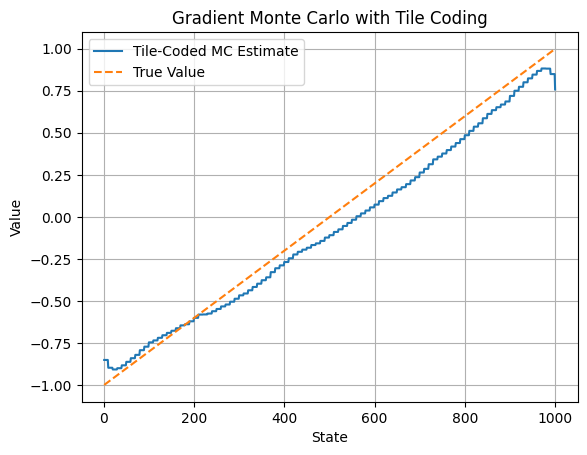

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
N_STATES    = 1000
START_STATE = 500
END_STATES  = [0, N_STATES + 1]
ACTION_LEFT  = -1
ACTION_RIGHT = 1
STEP_RANGE   = 100
STATES       = np.arange(1, N_STATES + 1)

# --- Environment Step ---
def step(state, action):
    stride = np.random.randint(1, STEP_RANGE + 1)
    next_state = state + action * stride
    next_state = max(0, min(N_STATES + 1, next_state))
    if   next_state == 0:
        reward = -1
    elif next_state == N_STATES + 1:
        reward = +1
    else:
        reward = 0
    return next_state, reward

# --- Random Policy ---
def get_action():
    return ACTION_RIGHT if np.random.rand() < 0.5 else ACTION_LEFT

# --- Tile Coder Function Approximator ---
class TileCoderVF:
    def __init__(self, num_tilings=10, tile_width=100):
        self.num_tilings = num_tilings
        self.tile_width  = tile_width
        # even offsets so tilings are interleaved
        self.offsets = [i * (tile_width / num_tilings)
                        for i in range(num_tilings)]
        # number of tiles per tiling (covers 0…1001)
        self.num_tiles = (N_STATES // tile_width) + 1
        # weight vector: one weight per (tiling, tile)
        self.weights = np.zeros(self.num_tilings * self.num_tiles)

    def _tiles(self, state):
        """Return the list of active feature indices for this state."""
        features = []
        for t_idx, offset in enumerate(self.offsets):
            pos = state + offset
            tile_idx = int(pos // self.tile_width)
            # clamp to valid tile range
            tile_idx = min(max(tile_idx, 0), self.num_tiles - 1)
            features.append(t_idx * self.num_tiles + tile_idx)
        return features

    def value(self, state):
        if state in END_STATES:
            return 0.0
        return np.sum(self.weights[self._tiles(state)])

    def update(self, delta, state):
        for feat in self._tiles(state):
            self.weights[feat] += delta

# --- Gradient Monte Carlo with Tile Coding ---
def gradient_mc(vf, alpha, num_episodes=100000):
    for ep in range(num_episodes):
        state = START_STATE
        trajectory = [state]

        # generate one episode
        while state not in END_STATES:
            action = get_action()
            state, _ = step(state, action)
            trajectory.append(state)

        # final return
        G = -1 if trajectory[-1] == 0 else +1

        # gradient MC update for each visited nonterminal
        for s in trajectory[:-1]:
            error = G - vf.value(s)
            # you can choose alpha_scaled = alpha / vf.num_tilings
            # to keep total step‐size constant
            delta = alpha * error
            vf.update(delta, s)

# --- Plotting (with true value) ---
def plot_mc(vf):
    approx = np.array([vf.value(s) for s in STATES])
    true_v = -1 + 2 * STATES / (N_STATES + 1)

    plt.plot(STATES, approx, label='Tile‑Coded MC Estimate')
    plt.plot(STATES, true_v,  '--', label='True Value')
    plt.xlabel('State')
    plt.ylabel('Value')
    plt.title('Gradient Monte Carlo with Tile Coding')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Run Experiment ---
if __name__ == '__main__':
    # try 10 tilings of width 100
    vf = TileCoderVF(num_tilings=10, tile_width=100)
    gradient_mc(vf, alpha=2e-5, num_episodes=100000)
    plot_mc(vf)


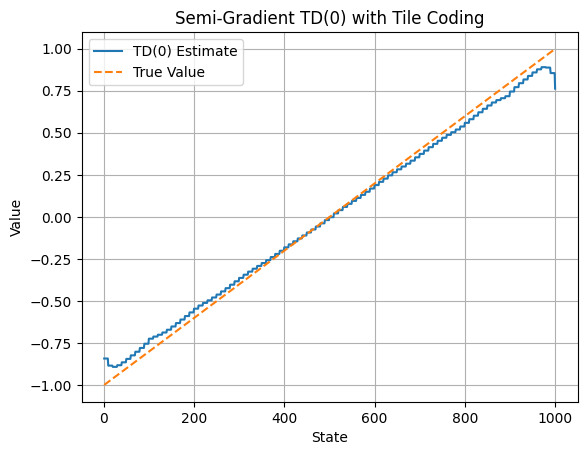

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
N_STATES    = 1000
START_STATE = 500
END_STATES  = [0, N_STATES + 1]
ACTION_LEFT  = -1
ACTION_RIGHT = 1
STEP_RANGE   = 100
STATES       = np.arange(1, N_STATES + 1)

# --- Environment Step ---
def step(state, action):
    stride = np.random.randint(1, STEP_RANGE + 1)
    next_state = state + action * stride
    next_state = max(0, min(N_STATES + 1, next_state))
    if   next_state == 0:
        reward = -1
    elif next_state == N_STATES + 1:
        reward = +1
    else:
        reward = 0
    return next_state, reward

# --- Random Policy ---
def get_action():
    return ACTION_RIGHT if np.random.rand() < 0.5 else ACTION_LEFT

# --- Tile Coder Function Approximator ---
class TileCoderVF:
    def __init__(self, num_tilings=10, tile_width=100):
        self.num_tilings = num_tilings
        self.tile_width  = tile_width
        self.offsets     = [i * (tile_width / num_tilings)
                            for i in range(num_tilings)]
        self.num_tiles   = (N_STATES // tile_width) + 1
        # one weight per tiling×tile
        self.weights     = np.zeros(self.num_tilings * self.num_tiles)

    def _tiles(self, state):
        feats = []
        for t_idx, off in enumerate(self.offsets):
            pos = state + off
            idx = int(pos // self.tile_width)
            idx = min(max(idx, 0), self.num_tiles - 1)
            feats.append(t_idx * self.num_tiles + idx)
        return feats

    def value(self, state):
        if state in END_STATES:
            return 0.0
        return np.sum(self.weights[self._tiles(state)])

    def update(self, delta, state):
        for feat in self._tiles(state):
            self.weights[feat] += delta

# --- Semi‑Gradient TD(0) ---
def semi_gradient_td(vf, alpha, num_episodes=100000):
    for ep in range(num_episodes):
        s = START_STATE
        while s not in END_STATES:
            a = get_action()
            s_next, r = step(s, a)

            v_s      = vf.value(s)
            v_next   = vf.value(s_next)
            delta    = r + v_next - v_s
            # update each active weight
            vf.update(alpha * delta, s)

            s = s_next

# --- Plotting with True Value ---
def plot_td(vf):
    approx = np.array([vf.value(s) for s in STATES])
    v_true = -1 + 2 * STATES / (N_STATES + 1)

    plt.plot(STATES, approx, label='TD(0) Estimate')
    plt.plot(STATES, v_true, '--', label='True Value')
    plt.xlabel('State')
    plt.ylabel('Value')
    plt.title('Semi‑Gradient TD(0) with Tile Coding')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Run ---
if __name__ == '__main__':
    vf = TileCoderVF(num_tilings=10, tile_width=100)
    semi_gradient_td(vf, alpha=1e-5, num_episodes=200000)
    plot_td(vf)


100%|██████████| 100000/100000 [00:46<00:00, 2130.92it/s]


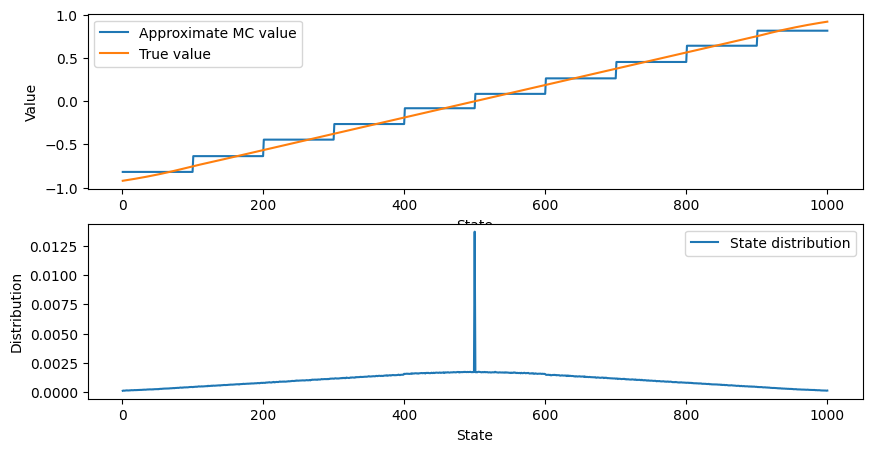

100%|██████████| 100/100 [02:05<00:00,  1.26s/it]


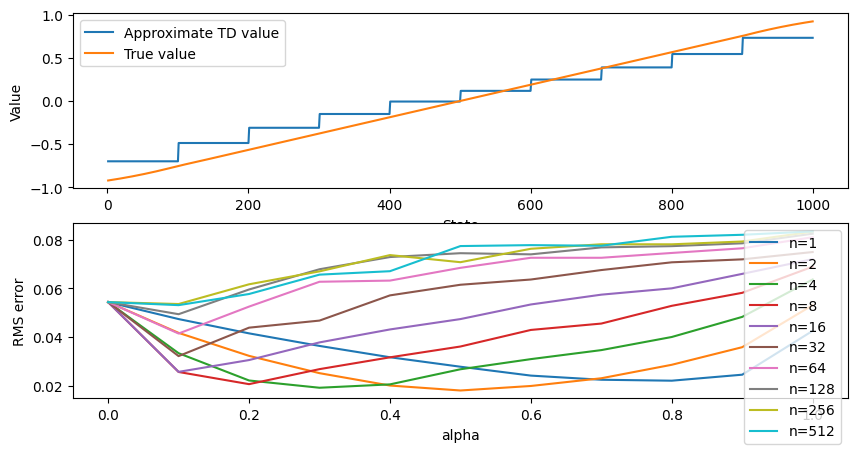

100%|██████████| 5000/5000 [04:40<00:00, 17.82it/s]


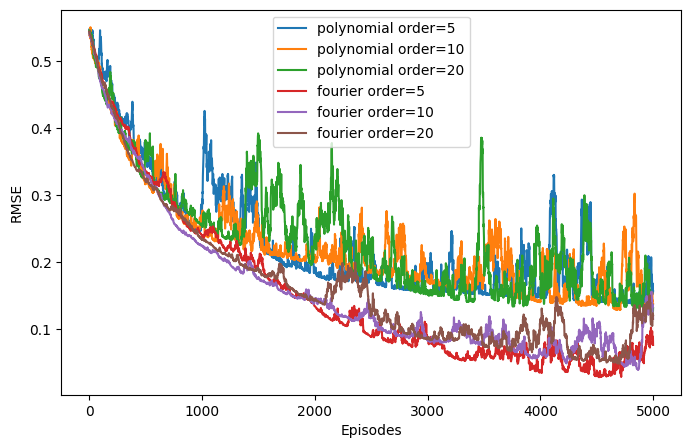

100%|██████████| 5000/5000 [00:06<00:00, 810.87it/s]


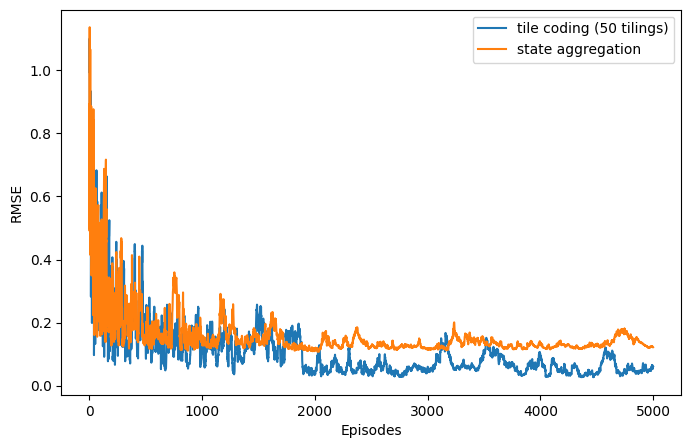

In [ ]:
#######################################################################
# Copyright (C)                                                       #
# 2016-2018 Shangtong Zhang(zhangshangtong.cpp@gmail.com)             #
# 2016 Kenta Shimada(hyperkentakun@gmail.com)                         #
# Permission given to modify the code as long as you keep this        #
# declaration at the top                                              #
#######################################################################

# In Colab, run this cell first to enable inline plotting:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# # of states except for terminal states
N_STATES = 1000

# all states
STATES = np.arange(1, N_STATES + 1)

# start from a central state
START_STATE = 500

# terminal states
END_STATES = [0, N_STATES + 1]

# possible actions
ACTION_LEFT = -1
ACTION_RIGHT = 1
ACTIONS = [ACTION_LEFT, ACTION_RIGHT]

# maximum stride for an action
STEP_RANGE = 100

def compute_true_value():
    # true state value, just a promising guess
    true_value = np.arange(-1001, 1003, 2) / 1001.0

    # Dynamic programming to find the true state values
    while True:
        old_value = np.copy(true_value)
        for state in STATES:
            true_value[state] = 0
            for action in ACTIONS:
                for step in range(1, STEP_RANGE + 1):
                    offset = step * action
                    next_state = state + offset
                    next_state = max(min(next_state, N_STATES + 1), 0)
                    true_value[state] += 1.0 / (2 * STEP_RANGE) * true_value[next_state]
        error = np.sum(np.abs(old_value - true_value))
        if error < 1e-2:
            break

    # correct the state value for terminal states to 0
    true_value[0] = true_value[-1] = 0
    return true_value

def step(state, action):
    step_size = np.random.randint(1, STEP_RANGE + 1) * action
    state = state + step_size
    state = max(min(state, N_STATES + 1), 0)
    if state == 0:
        reward = -1
    elif state == N_STATES + 1:
        reward = 1
    else:
        reward = 0
    return state, reward

def get_action():
    return ACTION_RIGHT if np.random.rand() < 0.5 else ACTION_LEFT

class ValueFunction:
    def __init__(self, num_of_groups):
        self.num_of_groups = num_of_groups
        self.group_size = N_STATES // num_of_groups
        self.params = np.zeros(num_of_groups)

    def value(self, state):
        if state in END_STATES:
            return 0
        idx = (state - 1) // self.group_size
        return self.params[idx]

    def update(self, delta, state):
        idx = (state - 1) // self.group_size
        self.params[idx] += delta

class TilingsValueFunction:
    def __init__(self, num_of_tilings, tile_width, tiling_offset):
        self.num_of_tilings = num_of_tilings
        self.tile_width = tile_width
        self.tiling_offset = tiling_offset
        self.tiling_size = N_STATES // tile_width + 1
        self.params = np.zeros((num_of_tilings, self.tiling_size))
        self.tilings = np.arange(-tile_width + 1, 0, tiling_offset)

    def value(self, state):
        if state in END_STATES:
            return 0
        val = 0.0
        for t_idx, offset in enumerate(self.tilings):
            tile_idx = (state - offset) // self.tile_width
            val += self.params[t_idx, tile_idx]
        return val

    def update(self, delta, state):
        delta /= self.num_of_tilings
        for t_idx, offset in enumerate(self.tilings):
            tile_idx = (state - offset) // self.tile_width
            self.params[t_idx, tile_idx] += delta

POLYNOMIAL_BASES = 0
FOURIER_BASES    = 1

class BasesValueFunction:
    def __init__(self, order, basis_type):
        self.order = order
        self.weights = np.zeros(order + 1)
        self.bases = []
        if basis_type == POLYNOMIAL_BASES:
            for i in range(order + 1):
                self.bases.append(lambda s, i=i: s**i)
        else:  # FOURIER_BASES
            for i in range(order + 1):
                self.bases.append(lambda s, i=i: np.cos(i * np.pi * s))

    def value(self, state):
        s = state / float(N_STATES)
        features = np.array([f(s) for f in self.bases])
        return np.dot(self.weights, features)

    def update(self, delta, state):
        s = state / float(N_STATES)
        features = np.array([f(s) for f in self.bases])
        self.weights += delta * features

def gradient_monte_carlo(value_function, alpha, distribution=None):
    state = START_STATE
    trajectory = [state]
    reward = 0.0
    while state not in END_STATES:
        action = get_action()
        next_state, reward = step(state, action)
        trajectory.append(next_state)
        state = next_state

    for s in trajectory[:-1]:
        delta = alpha * (reward - value_function.value(s))
        value_function.update(delta, s)
        if distribution is not None:
            distribution[s] += 1

def semi_gradient_temporal_difference(value_function, n, alpha):
    state = START_STATE
    states  = [state]
    rewards = [0]
    t = 0
    T = float('inf')
    while True:
        t += 1
        if t < T:
            action = get_action()
            next_state, reward = step(state, action)
            states.append(next_state)
            rewards.append(reward)
            if next_state in END_STATES:
                T = t
        tau = t - n
        if tau >= 0:
            G = sum(rewards[tau+1 : min(T, tau+n)+1])
            if tau + n <= T:
                G += value_function.value(states[tau + n])
            s_tau = states[tau]
            if s_tau not in END_STATES:
                delta = alpha * (G - value_function.value(s_tau))
                value_function.update(delta, s_tau)
        if tau == T - 1:
            break
        state = next_state

def figure_9_1(true_value):
    episodes = int(1e5)
    alpha = 2e-5
    vf = ValueFunction(10)
    dist = np.zeros(N_STATES + 2)
    for _ in tqdm(range(episodes)):
        gradient_monte_carlo(vf, alpha, dist)
    dist /= dist.sum()
    vals = [vf.value(s) for s in STATES]

    plt.figure(figsize=(10, 5))
    plt.subplot(2, 1, 1)
    plt.plot(STATES, vals, label='Approximate MC value')
    plt.plot(STATES, true_value[1:-1], label='True value')
    plt.xlabel('State')
    plt.ylabel('Value')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(STATES, dist[1:-1], label='State distribution')
    plt.xlabel('State')
    plt.ylabel('Distribution')
    plt.legend()
    plt.show()

def figure_9_2(true_value):
    plt.figure(figsize=(10, 5))
    # left: n=1
    episodes = int(1e5)
    alpha = 2e-4
    vf1 = ValueFunction(10)
    for _ in tqdm(range(episodes)):
        semi_gradient_temporal_difference(vf1, 1, alpha)
    vals1 = [vf1.value(s) for s in STATES]
    plt.subplot(2, 1, 1)
    plt.plot(STATES, vals1, label='Approximate TD value')
    plt.plot(STATES, true_value[1:-1], label='True value')
    plt.xlabel('State'); plt.ylabel('Value'); plt.legend()

    # right: multiple n, α combos
    steps  = 2**np.arange(0, 10)
    alphas = np.arange(0, 1.1, 0.1)
    episodes_small, runs = 10, 100
    errors = np.zeros((len(steps), len(alphas)))
    for _ in tqdm(range(runs)):
        for i, n in enumerate(steps):
            for j, a in enumerate(alphas):
                vf = ValueFunction(20)
                for _ in range(episodes_small):
                    semi_gradient_temporal_difference(vf, n, a)
                est = np.array([vf.value(s) for s in STATES])
                errors[i, j] += np.sqrt(np.mean((est - true_value[1:-1])**2))
    errors /= (runs * episodes_small)

    plt.subplot(2, 1, 2)
    for i, n in enumerate(steps):
        plt.plot(alphas, errors[i], label=f'n={n}')
    plt.xlabel('alpha'); plt.ylabel('RMS error'); plt.legend()
    plt.show()

def figure_9_5(true_value):
    episodes = 5000
    orders   = [5, 10, 20]
    alphas   = [1e-4, 5e-5]
    labels   = [['polynomial']*3, ['fourier']*3]
    errors   = np.zeros((2, 3, episodes))
    runs     = 1

    for _ in range(runs):
        for k, order in enumerate(orders):
            funcs = [
                BasesValueFunction(order, POLYNOMIAL_BASES),
                BasesValueFunction(order, FOURIER_BASES)
            ]
            for j, vf in enumerate(funcs):
                for ep in tqdm(range(episodes)):
                    gradient_monte_carlo(vf, alphas[j])
                    est = np.array([vf.value(s) for s in STATES])
                    errors[j, k, ep] += np.sqrt(np.mean((true_value[1:-1] - est)**2))
    errors /= runs

    plt.figure(figsize=(8, 5))
    for j in range(2):
        for k, order in enumerate(orders):
            plt.plot(errors[j, k], label=f'{labels[j][k]} order={order}')
    plt.xlabel('Episodes'); plt.ylabel('RMSE'); plt.legend()
    plt.show()

def figure_9_10(true_value):
    episodes = 5000
    runs     = 1
    num_t    = 50
    tile_w   = 200
    offset   = 4
    labels   = ['tile coding (50 tilings)', 'state aggregation']
    errors   = np.zeros((2, episodes))

    for _ in range(runs):
        vfs = [
            TilingsValueFunction(num_t, tile_w, offset),
            ValueFunction(N_STATES // tile_w)
        ]
        for i, vf in enumerate(vfs):
            for ep in tqdm(range(episodes)):
                alpha = 1.0 / (ep + 1)
                gradient_monte_carlo(vf, alpha)
                est = np.array([vf.value(s) for s in STATES])
                errors[i, ep] += np.sqrt(np.mean((true_value[1:-1] - est)**2))
    errors /= runs

    plt.figure(figsize=(8, 5))
    for i, label in enumerate(labels):
        plt.plot(errors[i], label=label)
    plt.xlabel('Episodes'); plt.ylabel('RMSE'); plt.legend()
    plt.show()

if __name__ == '__main__':
    true_value = compute_true_value()
    figure_9_1(true_value)
    figure_9_2(true_value)
    figure_9_5(true_value)
    figure_9_10(true_value)
